# VAE

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim

from utils.train import train
from utils.scheduler import exponential_decay
from utils.data_processor import create_flower_dataloaders, show_recover_results

In [ ]:
# Set seeds
torch.manual_seed(0)
np.random.seed(0)

data_root = "../../Data/flowers"
model_save_root = "../../Models"

batch_size = 16
img_width, img_height = 24, 24

training_dataloader, validation_dataloader = create_flower_dataloaders(batch_size, data_root, img_width, img_height)
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"

In [4]:
from VAE import VAE, VAE_loss_function, VAE_ENCODING_DIM

#### Train

In [5]:
num_epochs = 30   
early_stopping_patience = 5
lr = 1e-3

model = VAE(VAE_ENCODING_DIM) 
    
loss_fn = VAE_loss_function 

optimizer = optim.Adam(
    model.parameters(),
    lr=lr,
    betas=(0.9, 0.999),
    weight_decay=1e-5
)
scheduler = exponential_decay(
    initial_learning_rate=lr,
    decay_rate=0.8,      
    decay_epochs=5       
)

model.to(device)

# Start training
train(
    optimizer=optimizer,
    scheduler=scheduler,
    model=model,
    training_dataloader=training_dataloader,
    validation_dataloader=validation_dataloader,
    num_epochs=num_epochs,
    early_stopping_patience=early_stopping_patience,
    device=device,
    model_save_root=model_save_root,
    loss_fn=loss_fn,
)

Model saved at epoch 0, val_loss=1026.033610
Epoch: 0, Train Loss: 1299.7287212665265, Valid Loss: 1026.0336100260417
Epoch: 1, Train Loss: 1002.8421447753906, Valid Loss: 1026.0336100260417
Epoch: 2, Train Loss: 961.1059875488281, Valid Loss: 1026.0336100260417
Model saved at epoch 3, val_loss=867.295858
Epoch: 3, Train Loss: 881.5801321176382, Valid Loss: 867.2958577473959
Epoch: 4, Train Loss: 840.9817028339093, Valid Loss: 867.2958577473959
Epoch: 5, Train Loss: 800.095937875601, Valid Loss: 867.2958577473959
Model saved at epoch 6, val_loss=771.516546
Epoch: 6, Train Loss: 779.4967989408053, Valid Loss: 771.5165460759944
Epoch: 7, Train Loss: 768.902456665039, Valid Loss: 771.5165460759944
Epoch: 8, Train Loss: 764.2478024996244, Valid Loss: 771.5165460759944
Model saved at epoch 9, val_loss=755.101569
Epoch: 9, Train Loss: 763.7435650165264, Valid Loss: 755.1015689734256
Epoch: 10, Train Loss: 750.3740379920373, Valid Loss: 755.1015689734256
Epoch: 11, Train Loss: 750.07086029052

#### Visualization

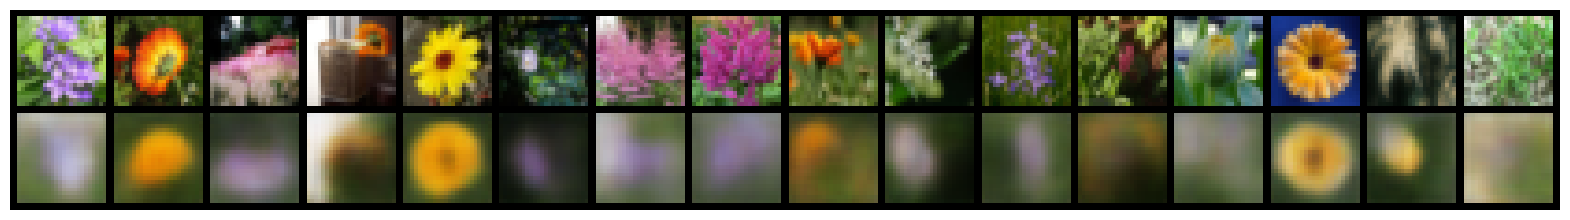

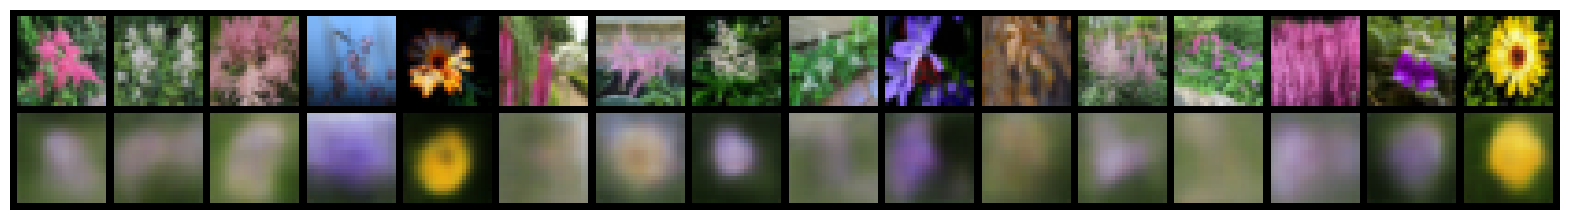

In [ ]:
model_ckpt = os.path.join(model_save_root,f"Best_{model.name}.pth")

model = VAE(VAE_ENCODING_DIM) 
model.load_state_dict(torch.load(model_ckpt))
model.eval()
model.to(device)

# visualize the results
train_images_sampled = next(iter(training_dataloader))[0].to(device)
valid_images_sampled = next(iter(validation_dataloader))[0].to(device)

train_outputs = model(train_images_sampled)[0]
valid_outputs = model(valid_images_sampled)[0]

show_recover_results(train_images_sampled, train_outputs)
show_recover_results(valid_images_sampled, valid_outputs)

#### Random sample

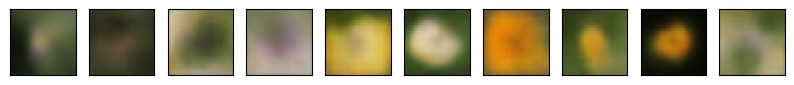

In [ ]:
model_save_path = os.path.join(model_save_root,f"Best_{model.name}.pth")

model = VAE(VAE_ENCODING_DIM) 
model.load_state_dict(torch.load(model_save_path))
model.eval()

with torch.no_grad():
    z = torch.randn(10, VAE_ENCODING_DIM)
    random_images = model.decoder(z)
    random_images = torch.clamp(random_images, 0.0, 1.0)

fig = plt.figure(figsize=(10, 1))

for i in range(10):
    ax = fig.add_subplot(1, 10, i + 1, xticks=[], yticks=[])
    ax.imshow(np.transpose(random_images[i].detach().numpy(), (1, 2, 0)))